# Cox生存分析

* `mydir`：自己的数据
* `ostime_column`: 数据对应的生存时间，不一定非的是OST，也可以是DST、FST等。
* `os`：生存状态，不一定非的是OS，也可以是DS、FS等。

In [1]:
import os
from IPython.display import display
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd
import pandas as pd

os.makedirs('img', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('features', exist_ok=True)

# 设置数据目录
event_col = get_param_in_cwd('event_col')
duration_col = get_param_in_cwd('duration_col')
task_type = f'Clinical_'
# 对应的标签文件
group_info = get_param_in_cwd('dataset_column') or 'group'
survival_data = pd.read_csv(get_param_in_cwd('label_file'))[['ID', event_col, duration_col]]
# survival_data = pd.merge(survival_data, pd.read_csv('group.csv'), on='ID', how='inner')
# 读取标签数据列名
labels = [get_param_in_cwd('task_column') or 'label']
survival_data

,ID,event,duration
0,J07A1030,0,130
1,J07A0977,0,141
2,J07A1049,0,128
3,J07A3085,0,127
4,J07A0963,1,18
...,...,...,...
273,J07A3185,0,102
274,J07A3162,0,117
275,J07A1133,0,107
276,J07A1128,0,108


In [2]:
from lifelines import CoxPHFitter
import pandas as pd
from onekey_algo.custom.components.comp1 import normalize_df
from sklearn.model_selection import train_test_split
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.components.comp1 import fillna

data = pd.read_csv('data/clinical.csv', dtype={'ID':str})
# data = pd.merge(data, survival_data.drop_duplicates(), on='ID', how='inner')
data = data[[c for c in data.columns if c not in set([duration_col, event_col])]]
# data = normalize_df(data, not_norm=['ID', 'group'])
# label_data = pd.read_csv(get_param_in_cwd('label_file'), dtype={'ID':str})[['ID', event_col, duration_col]]
# label_data['ID'] = label_data['ID'].map(lambda x: f"{int(x)}.nii.gz")
data = pd.merge(data, survival_data, on='ID', how='inner')
data

,ID,number_of_lymph_nodes,positive_number,T,N,M,AJCC,HER2,age,group,event,duration
0,J07A3054,14,0,1,0,0,1,0,56,train,0,132
1,J07A3055,15,0,2,0,0,2,0,51,train,0,131
2,J07A3056,25,9,2,3,0,3,1,39,train,1,78
3,J07A3057,18,2,1,1,0,2,1,60,train,0,131
4,J07A3058,17,0,1,0,0,1,1,55,test,0,131
...,...,...,...,...,...,...,...,...,...,...,...,...
273,J07A0934,13,0,2,0,1,2,1,37,train,0,149
274,J07A0939,21,21,3,3,1,3,0,50,train,0,147
275,J07A1062,10,2,1,1,1,2,0,46,test,0,119
276,J07A1080,11,0,1,0,1,1,1,65,test,0,115


In [3]:
import numpy as np
import onekey_algo.custom.components as okcomp
from collections import OrderedDict

group_info = 'group'
train_data = data[(data[group_info] == 'train')]

# subsets = [s for s in label_data['group'].value_counts().index if s != 'train']
subsets = get_param_in_cwd('subsets')
val_datasets = OrderedDict()
for subset in subsets:
    val_data = data[data[group_info] == subset]
    val_datasets[subset] = val_data
    val_data.to_csv(f'features/{task_type}{subset}_features_norm.csv', index=False)

print('，'.join([f"{subset}样本数：{d_.shape}" for subset, d_ in val_datasets.items()]))

train样本数：(194, 12)，test样本数：(84, 12)


In [4]:
import os
from onekey_algo.custom.components.survival import uni_cox

if os.path.exists(f'features/{task_type}rad_features_unisel.csv') and False:
    train_data = pd.read_csv(f'features/{task_type}rad_features_unisel.csv')
else:
    sel_features, uni_info = uni_cox(train_data, duration_col=duration_col, event_col=event_col,
                                     cols=[c for c in train_data.columns if c not in [event_col, duration_col, 'ID', 'group']], 
                                     pvalue_thres=0.05, verbose=True)
    train_data = train_data[['ID'] + sel_features + [event_col, duration_col, 'group']]
    data[['ID'] + sel_features + [event_col, duration_col, 'group']].to_csv(f'features/{task_type}rad_features_unisel.csv', header=True, index=False)
train_data

[2025-09-12 22:27:59 - survival.py:  49]	INFO	number_of_lymph_nodes的pvalue: 0.40624961580390184
[2025-09-12 22:27:59 - survival.py:  49]	INFO	positive_number的pvalue: 0.07322904891741368
[2025-09-12 22:27:59 - survival.py:  49]	INFO	T的pvalue: 0.20884347315184784
[2025-09-12 22:27:59 - survival.py:  49]	INFO	N的pvalue: 0.010116105166543623
[2025-09-12 22:27:59 - survival.py:  49]	INFO	M的pvalue: 0.30984028681430953
[2025-09-12 22:27:59 - survival.py:  49]	INFO	AJCC的pvalue: 0.0029899990150534985
[2025-09-12 22:27:59 - survival.py:  49]	INFO	HER2的pvalue: 0.7505548904957026
[2025-09-12 22:27:59 - survival.py:  49]	INFO	age的pvalue: 0.047063001329657954


,ID,N,AJCC,age,event,duration,group
0,J07A3054,0,1,56,0,132,train
1,J07A3055,0,2,51,0,131,train
2,J07A3056,3,3,39,1,78,train
3,J07A3057,1,2,60,0,131,train
6,J07A3060,2,3,47,0,130,train
...,...,...,...,...,...,...,...
265,J07A1125,0,1,71,0,109,train
269,J07A1130,2,3,54,1,9,train
272,J07A0929,0,2,48,0,150,train
273,J07A0934,0,2,37,0,149,train


## Cox概览

所有Cox回归的必要数据，主要关注的数据有3个
1. `Concordance`: c-index
2. `exp(coef)`: 每个特征对应的HR，同时也有期对应的95%分位数。
3. `p`: 表示特征是否显著。

In [5]:
from lifelines import CoxPHFitter
mci = 0
for p in range(100):
    cph = CoxPHFitter(penalizer=p/100)
    cph.fit(train_data[[c for c in train_data.columns if c not in ['ID', 'group']]], duration_col=duration_col, event_col=event_col)
    test_data = val_datasets['test']
    ci = cph.score(test_data[[c for c in test_data.columns if c not in ['ID', 'group']]], scoring_method="concordance_index")
    if mci < ci:
        print(p, ci)
        mci = ci

0 0.8071718538565629
1 0.8085250338294994
2 0.8098782138024357
3 0.8139377537212449
4 0.8152909336941814
6 0.8179972936400541
35 0.8193504736129905
78 0.8207036535859269


In [6]:
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.0)
cph.fit(train_data[[c for c in train_data.columns if c not in ['ID', 'group']]], duration_col=duration_col, event_col=event_col)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 194 total observations, 139 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 194
number of events observed = 55
   partial log-likelihood = -267.03
         time fit was run = 2025-09-12 14:28:03 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
N           0.03       1.03       0.28            -0.51             0.58                 0.60                 1.78
AJCC        0.83       2.29       0.44            -0.04             1.70                 0.96                 5.47
age         0.03       1.03       0.01             0.01             0.06                 1.01                 1.06

            cmp to    z      p   -log2(p)
covariate                                
N             0.00 0.12   0.91       0.14
AJCC          0.00 1.86   0.06       4.00
age           0.00 2.96 <0.005       8.36
---
Concordance = 0.68
Partial AIC = 540.06
log-likelihood ratio test = 21.24 on 3 df
-log2(p) of ll-ratio test = 13.38

In [7]:
multi_info = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].reset_index()
i = pd.merge(uni_info, multi_info, on='covariate', how='left', suffixes=['_Uni', '_Multi'])
multi_data = data[['ID'] + list(multi_info[multi_info['p'] < 0.05]['covariate'])]
multi_data.to_csv(f'features/{task_type}rad_features_mulsel.csv', header=True, index=False)
i['p_Uni'] = i['p_Uni'].map(lambda x: '<0.05' if not pd.isna(x) and x < 0.05 else x)
i['p_Multi'] = i['p_Multi'].map(lambda x: '<0.05' if not pd.isna(x) and x < 0.05 else x)
i.columns = ['features_name', 'HR', 'lower 95%CI', 'upper 95%CI', 'pvalue', 'HR', 'lower 95%CI', 'upper 95%CI', 'pvalue']
i.applymap(lambda x: '' if pd.isna(x) else x)

,features_name,HR,lower 95%CI,upper 95%CI,pvalue,HR,lower 95%CI,upper 95%CI,pvalue
0,number_of_lymph_nodes,0.978,0.928,1.031,0.406,,,,
1,positive_number,1.044,0.996,1.094,0.073,,,,
2,T,1.311,0.859,1.999,0.209,,,,
3,N,1.345,1.073,1.687,<0.05,1.033,0.598,1.785,0.906
4,M,1.269,0.801,2.008,0.31,,,,
5,AJCC,1.704,1.198,2.421,<0.05,2.289,0.958,5.472,0.062
6,HER2,0.922,0.557,1.525,0.751,,,,
7,age,1.019,1.000,1.039,<0.05,1.035,1.012,1.058,<0.05


#### 输出每个特征的HR

In [8]:
cph.concordance_index_

0.6832714173139705

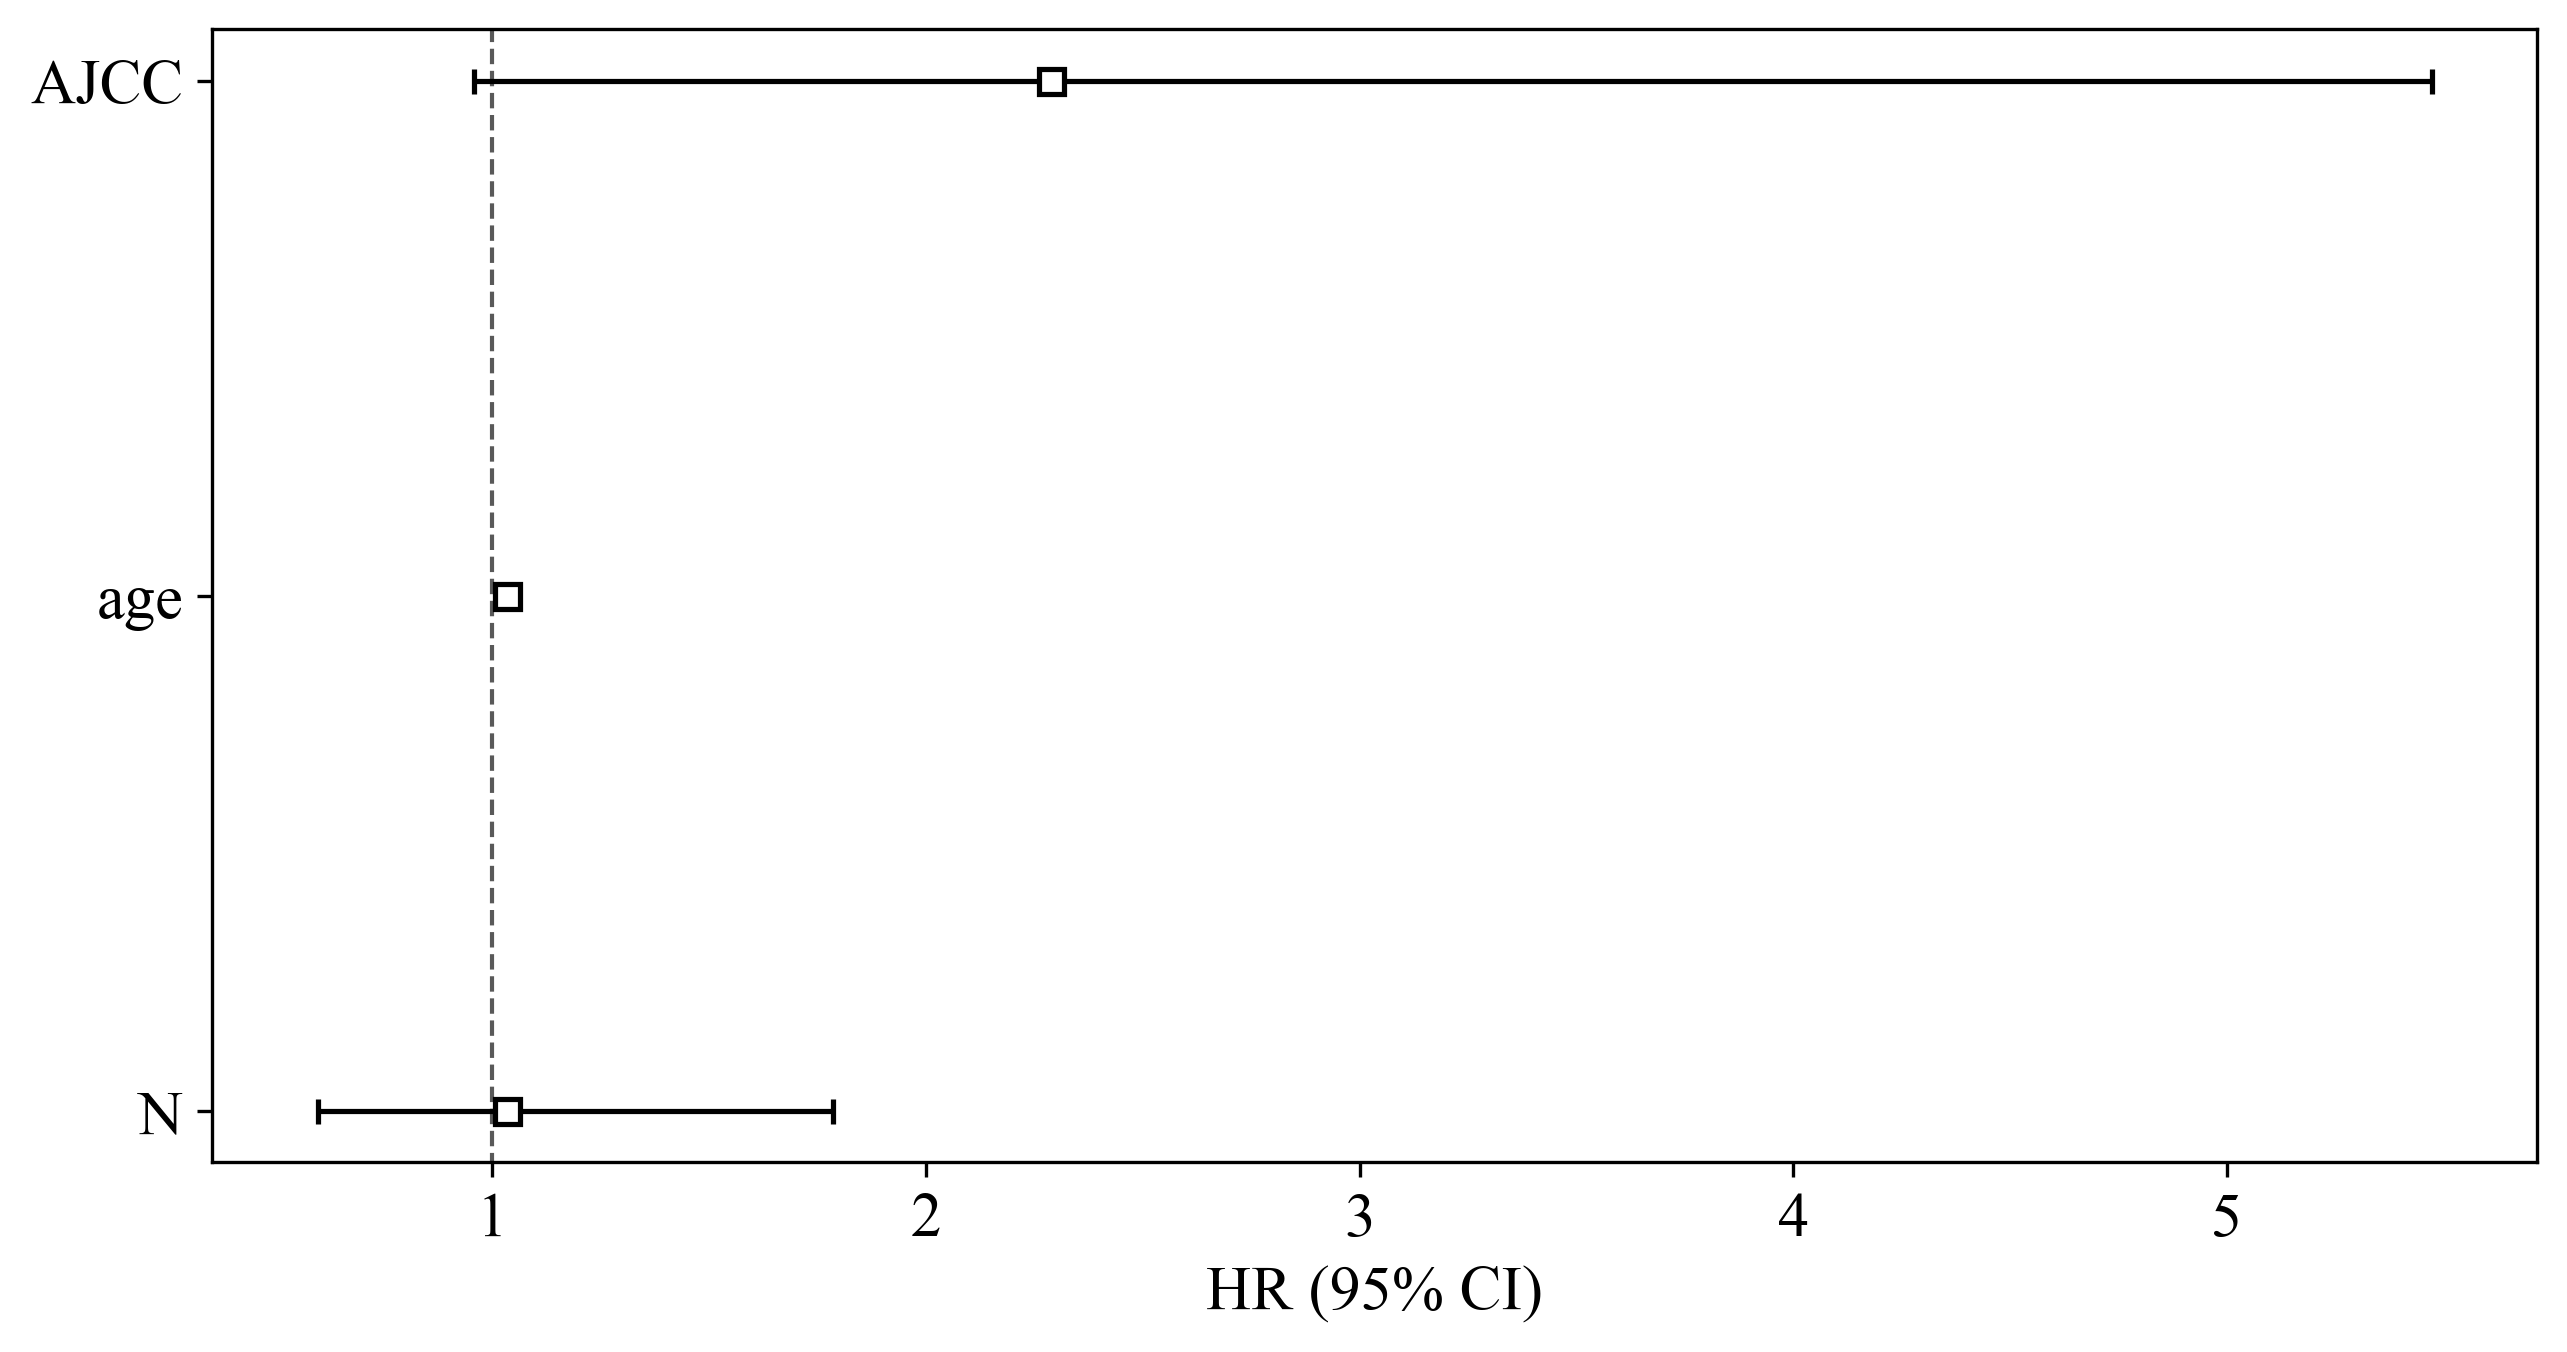

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
cph.plot(hazard_ratios=True)
plt.savefig('img/Clinic_feature_pvalue.svg')
plt.show()

# KM 曲线

根据HR进行分组，计算KM以及log ranktest

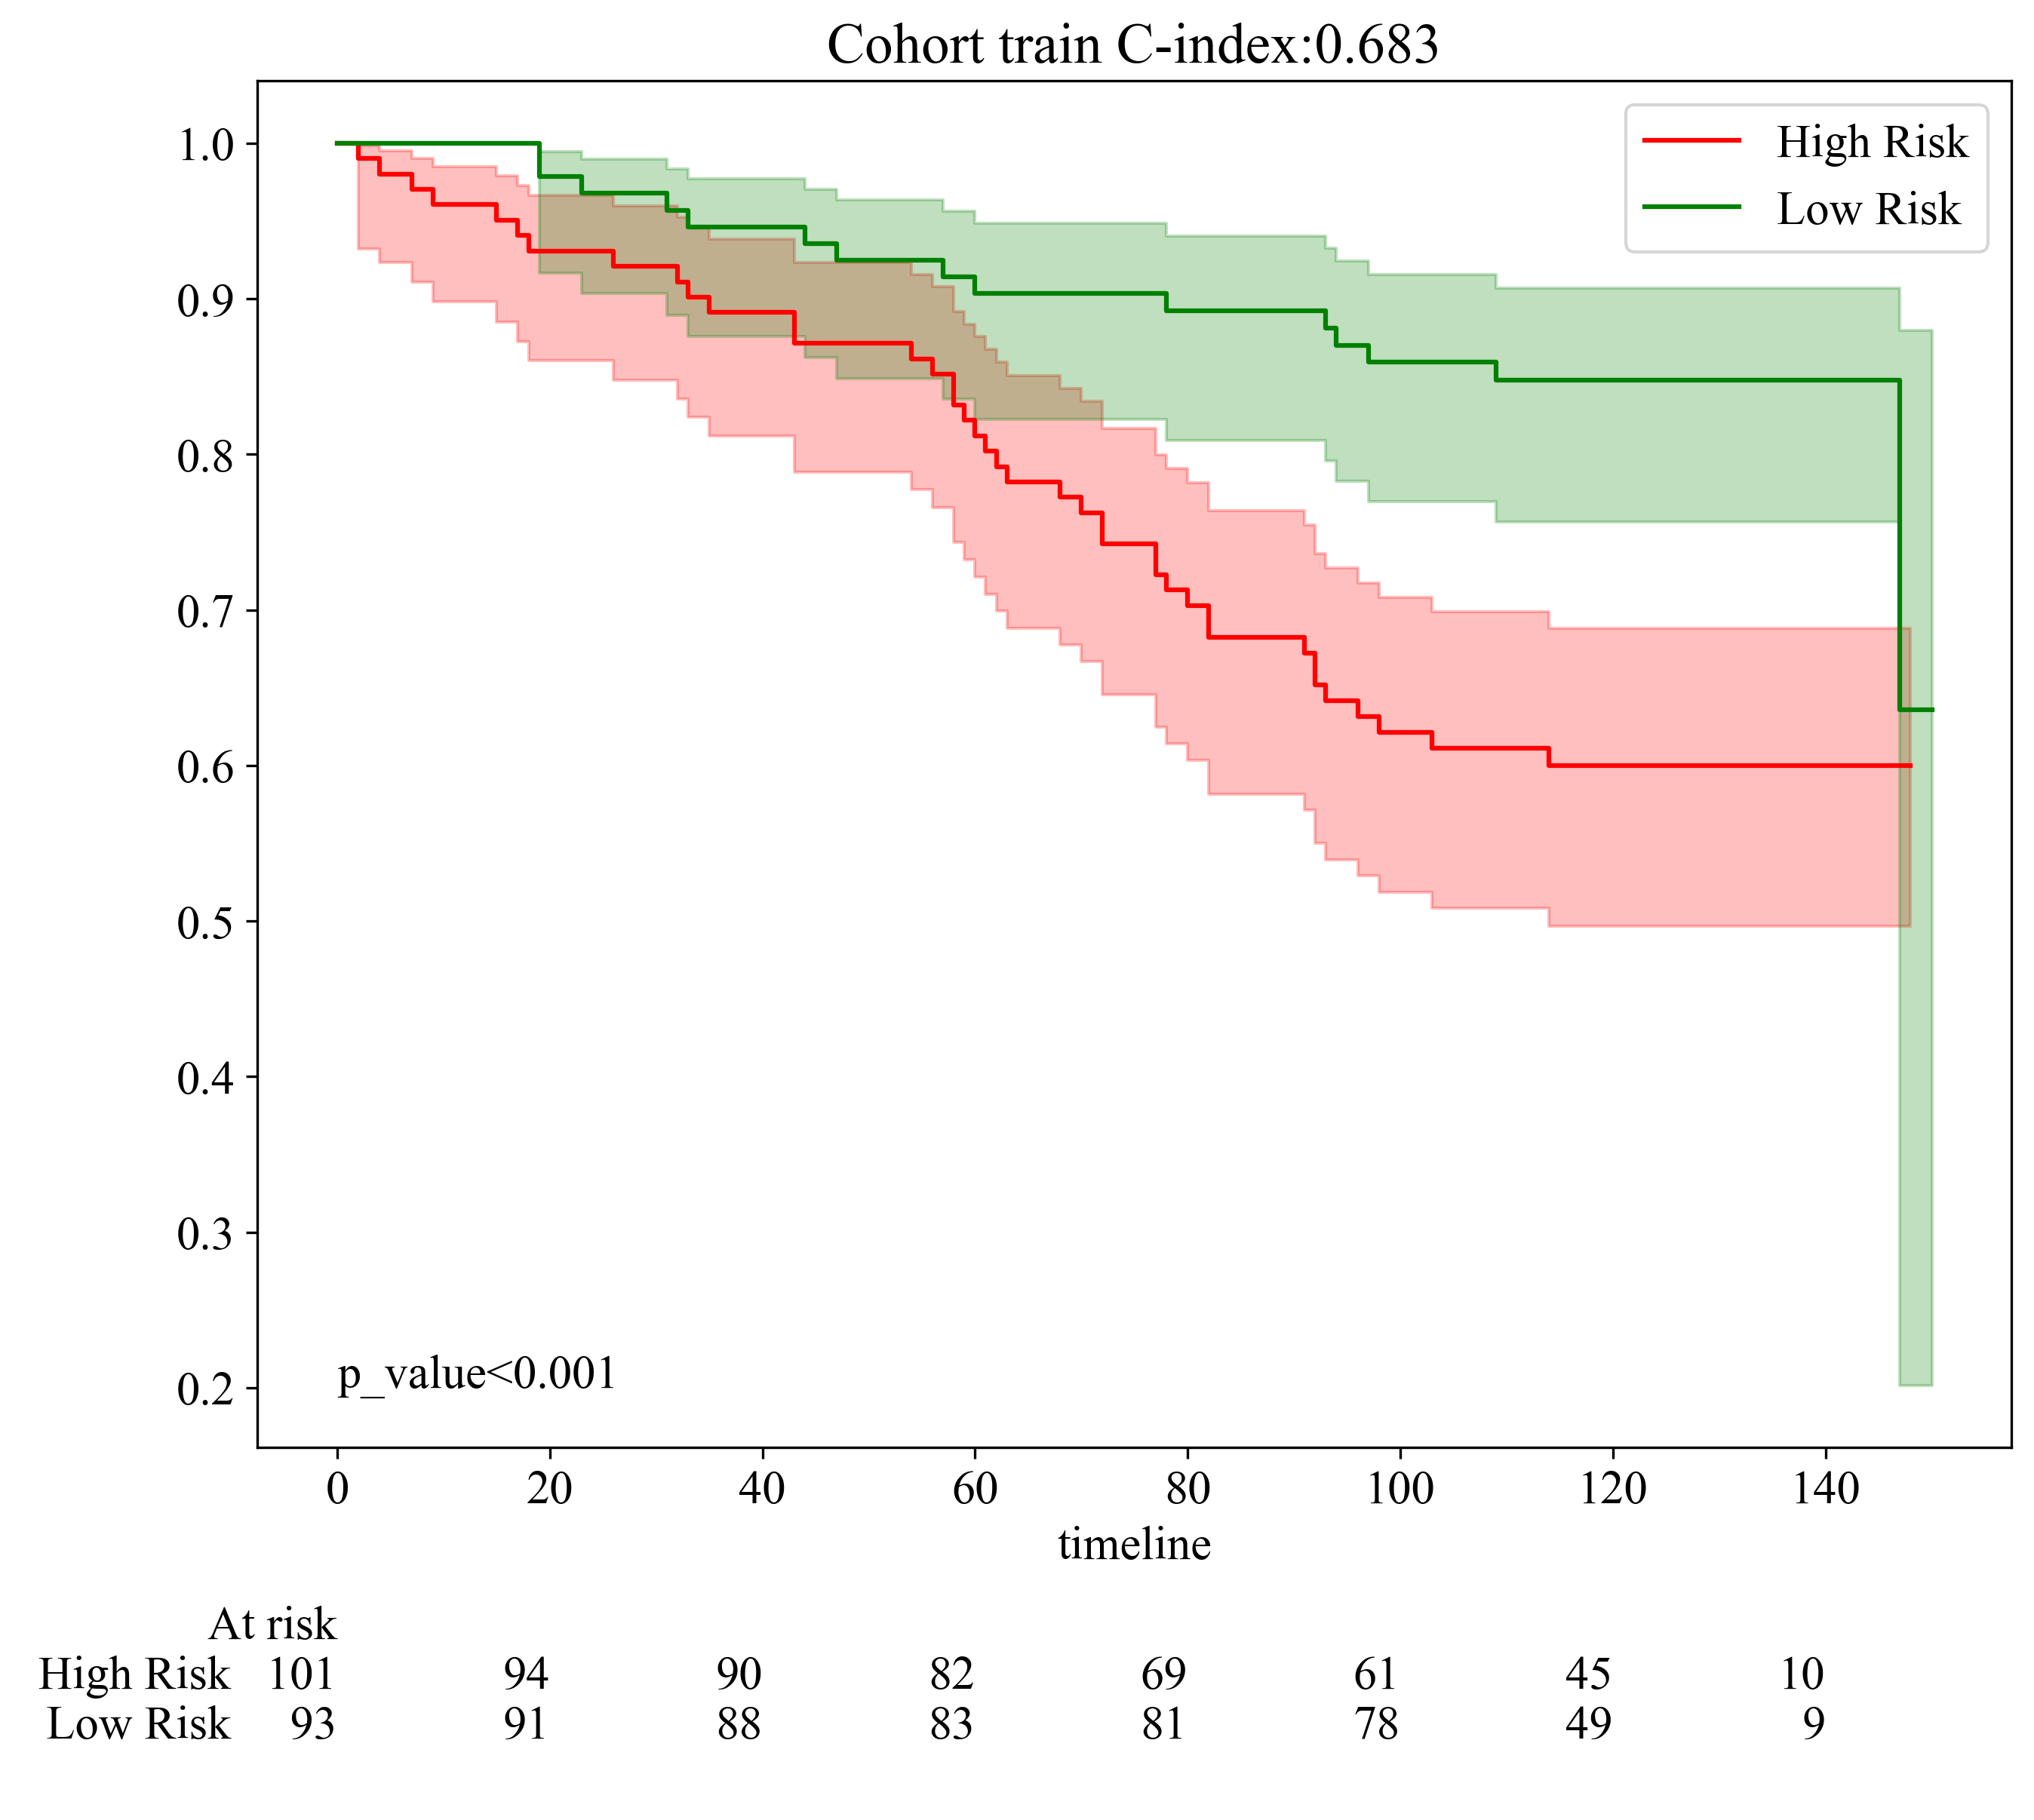

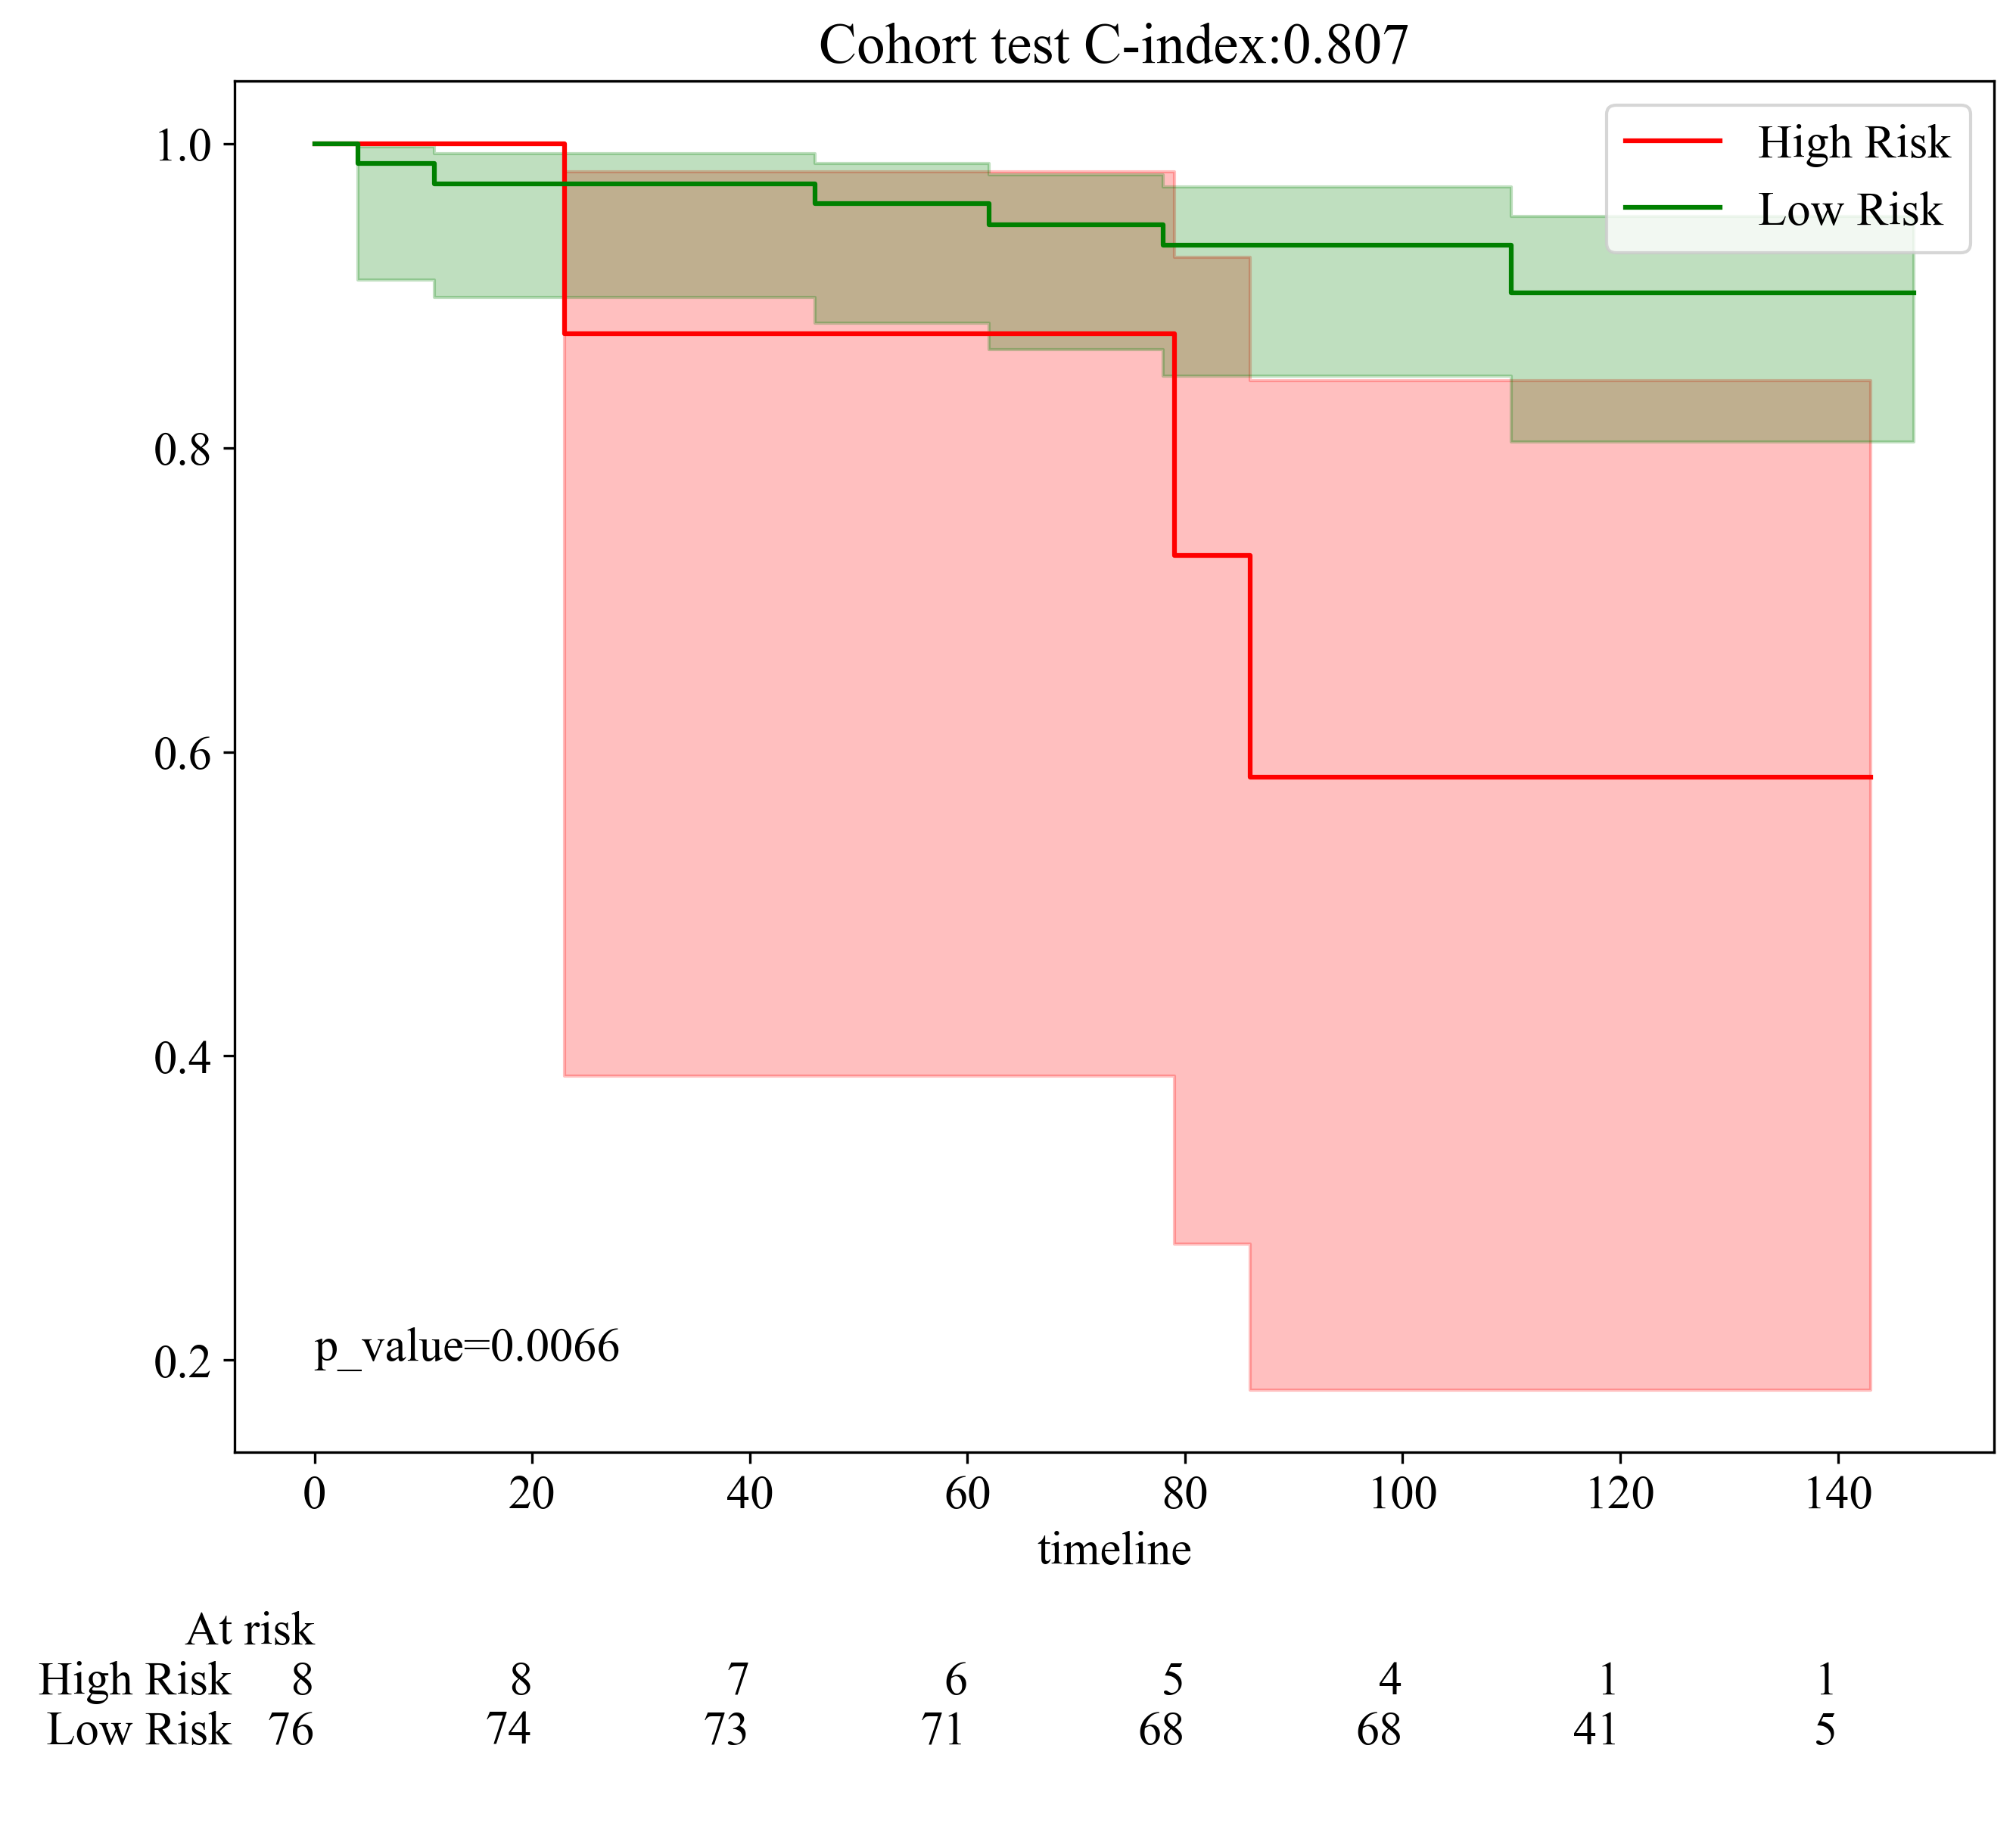

In [10]:
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

thres = 0.001

bst_split = {'train': 1.03, 'val':1.06, 'test': 2.55, 'KH':0.57, 'CY':0.57}
loc = {'train': 0.2, 'val':0.2, 'ZD': 0.2, 'KH':0.2, 'CY':0.2}
for subset, test_data in val_datasets.items():
    c_index = cph.score(test_data[[c for c in test_data.columns if c != 'ID']], scoring_method="concordance_index")
#     y_pred = cph.predict_median(test_data[[c for c in test_data.columns if c != 'ID']])
#     cox_data = pd.concat([test_data, y_pred], axis=1)
#     mean = cox_data.describe()[0.5]['mean']
#     cox_data['HR'] = cox_data[0.5] < mean
    y_pred = cph.predict_partial_hazard(test_data[[c for c in test_data.columns if c != 'ID']])
    cox_data = pd.concat([test_data, y_pred], axis=1)
#     mean = cox_data.describe()[0]['50%']
    cox_data['HR'] = cox_data[0] > bst_split[subset] if subset in bst_split else 1
#     cox_data['HR'] = cox_data[0] > mean

    dem = (cox_data["HR"] == True)
    results = logrank_test(cox_data[duration_col][dem], cox_data[duration_col][~dem], 
                           event_observed_A=cox_data[event_col][dem], event_observed_B=cox_data[event_col][~dem])
    p_value = f"={results.p_value:.4f}" if results.p_value > thres else f'<{thres}'
    plt.title(f"Cohort {subset} C-index:{c_index:.3f}")
    if sum(dem):
        kmf_high = KaplanMeierFitter()
        kmf_high.fit(cox_data[duration_col][dem], event_observed=cox_data[event_col][dem], label="High Risk")
        kmf_high.plot_survival_function(color='r')
    if sum(~dem):
        kmf_low = KaplanMeierFitter()
        kmf_low.fit(cox_data[duration_col][~dem], event_observed=cox_data[event_col][~dem], label="Low Risk")
        kmf_low.plot_survival_function(color='g')
    plt.text(0.0, loc[subset] if subset in loc else 0.2, f"p_value{p_value}")
    add_at_risk_counts(kmf_high, kmf_low, rows_to_show=['At risk'])
    plt.savefig(f'img/{task_type}KM_{subset}.svg', bbox_inches='tight')
    plt.show()

In [11]:
import os
import numpy as np

def get_prediction(model: CoxPHFitter, data, ID=None, **kwargs):
    hr = model.predict_partial_hazard(data)
    expectation = model.predict_expectation(data)
    
    predictions = pd.concat([hr, expectation], axis=1)
    predictions.columns = ['HR', 'expectation']
    if ID is not None:
        predictions = pd.concat([ID, hr, expectation], axis=1)
        predictions.columns = ['ID', 'HR', 'expectation']
    else:
        predictions = pd.concat([hr, expectation], axis=1)
        predictions.columns = ['HR', 'expectation']
    return predictions

os.makedirs('results', exist_ok=True)
info = []
for subset, test_data in val_datasets.items():
    if subset in get_param_in_cwd('subsets'):
        results = get_prediction(cph, test_data, ID=test_data['ID'])
        results.to_csv(f'results/{task_type}cox_predictions_{subset}.csv', index=False)
        results['group'] = subset
        info.append(results)
        pd.merge(results, data[['ID', event_col, duration_col]], on='ID', how='inner').to_csv(f'features/{task_type}4xtile_{subset}.txt', 
                                                                                                    index=False, sep='\t')
info = pd.concat(info, axis=0)
info.to_csv(f'results/{task_type}cox_predictions.csv', index=False)
info

,ID,HR,expectation,group
0,J07A3054,0.384,138.600,train
1,J07A3055,0.740,130.586,train
2,J07A3056,1.241,120.398,train
3,J07A3057,1.040,124.339,train
6,J07A3060,1.578,114.160,train
...,...,...,...,...
270,J07A1132,0.562,134.498,test
271,J07A1133,0.740,130.586,test
275,J07A1062,0.645,132.666,test
276,J07A1080,0.522,135.418,test
